In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from constants import con
from diff_eq import diff_eq  


In [7]:
con.ISO=0
con.CQ_tot = 10.0      # [mM] WT value
con.k_fCQ = 0.534      # [1/(mM*ms)] WT value

c:\Users\Meital\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
c:\Users\Meital\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\integrate\_ivp\common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


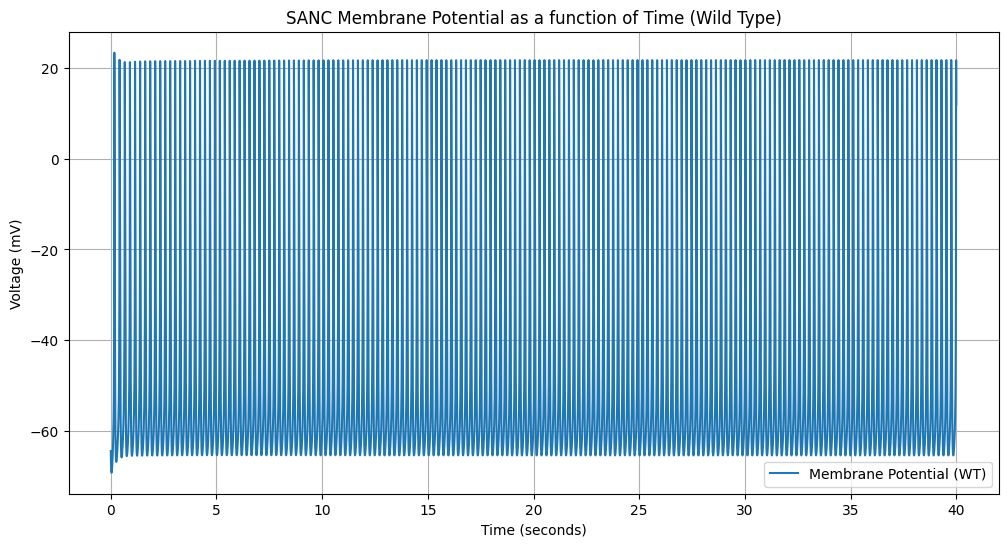

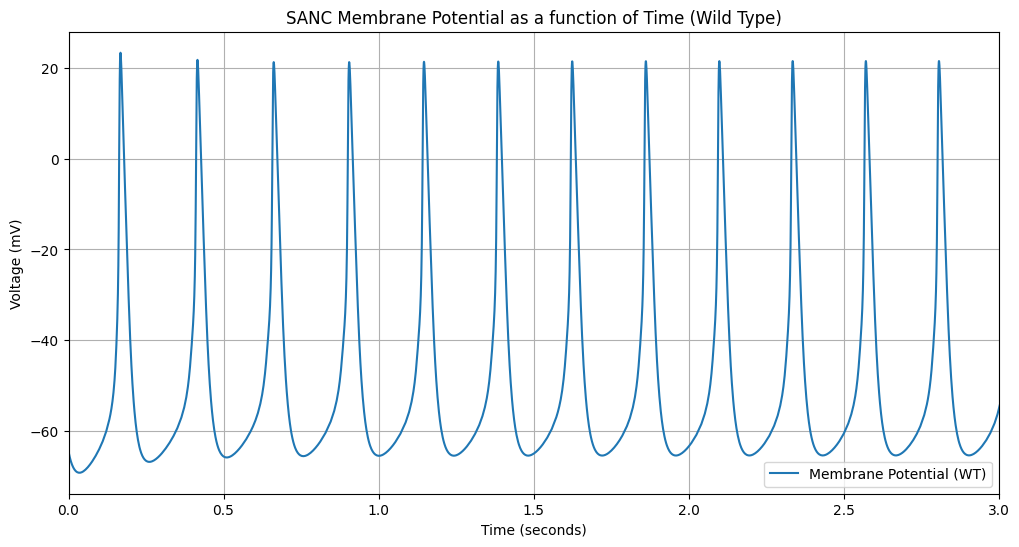

In [8]:
# ---------- Initial conditions ----------
Y0 = np.zeros(43)

Y0[0]  = -64.5216286940   # Vm
Y0[1]  = 0.6246780312     # qa
Y0[2]  = 0.4537033169     # qi
Y0[3]  = 0.0016256324     # dT
Y0[4]  = 0.4264459666     # fT
Y0[5]  = 0.4043600437     # pa
Y0[6]  = 0.9250035423     # pi
Y0[7]  = 0.0127086259     # xs
Y0[8]  = 0.9968141226     # fL12
Y0[9]  = 0.0000045583     # dL12
Y0[10] = 0.9809298233     # fL13
Y0[11] = 0.0002036671     # dL13
Y0[12] = 0.7649576191     # fCa
Y0[13] = 0.0046263658     # r
Y0[14] = 0.6107148187     # q
Y0[15] = 0.4014088304     # m15
Y0[16] = 0.2724817537     # h15
Y0[17] = 0.0249208708     # j15
Y0[18] = 0.1079085266     # m11
Y0[19] = 0.4500098710     # h11
Y0[20] = 0.0268486392     # j11
Y0[21] = 0.0279984462     # y
Y0[22] = 0.0000319121     # Cai
Y0[23] = 0.1187281829     # CajSR
Y0[24] = 1.5768287365     # CanSR
Y0[25] = 0.0000560497     # Casub
Y0[26] = 0.0063427103     # fTC
Y0[27] = 0.1296677919     # fTMC
Y0[28] = 0.7688656371     # fTMM
Y0[29] = 0.0242054739     # fCMs
Y0[30] = 0.0138533048     # fCMi
Y0[31] = 0.1203184861     # fCQ
Y0[32] = 0.7720290515     # R
Y0[33] = 7.60e-8          # OO
Y0[34] = 2.13e-8          # S
Y0[35] = 0.2162168926     # RI
Y0[36] = 0.0004           # w
Y0[37] = 19.73            # cAMP
Y0[38] = 0.23             # PLB
Y0[39] = 0.06             # A
Y0[40] = 0.02             # TT
Y0[41] = 0.06             # U
Y0[42] = 1.75e-6          # SL

# %% *************************Add your code here**************************

# --- Question 4 ---
# Define the time span for the simulation: 40 seconds * 1000 = 40,000 ms
t_start = 0
t_end = 40000
t_span = (t_start, t_end)

# Call the ODE solver (solve_ivp)
sol = solve_ivp(diff_eq, t_span, Y0, method='BDF')

# Extract the results
time_ms = sol.t          # Time points in milliseconds
voltage_mv = sol.y[0]    # Membrane potential (Vm) is the first variable in our Y vector

# Display the membrane voltage as a function of time 
plt.figure(figsize=(12, 6))
plt.plot(time_ms / 1000, voltage_mv, label='Membrane Potential (WT)') # Convert ms to seconds for the x-axis
plt.title('SANC Membrane Potential as a function of Time (Wild Type)')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time_ms / 1000, voltage_mv, label='Membrane Potential (WT)') # Convert ms to seconds for the x-axis
plt.title('SANC Membrane Potential as a function of Time (Wild Type)')
plt.xlabel('Time (seconds)')
plt.xlim(0,3)
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.legend()
plt.show()

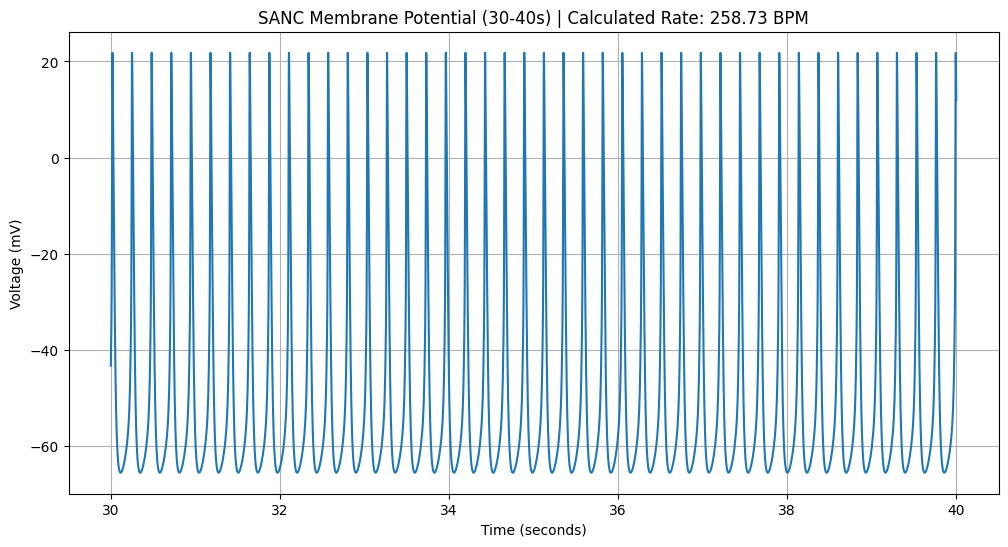

Average Cycle Length (CL): 231.90 ms
Calculated Beating Rate: 258.73 BPM


In [9]:
# --- Question 5 ---

# Focus on the last 10 seconds of the simulation (30s to 40s)
start_time = 30000 # ms
end_time = 40000   # ms
indices = np.where((time_ms >= start_time) & (time_ms <= end_time))[0]

time_segment = time_ms[indices]
voltage_segment = voltage_mv[indices]

# Peak Detection Algorithm
# We identify a peak if a point is higher than its neighbors and above a 0 mV to avoid noise.
peaks_time = []
threshold = 0 

for i in range(1, len(voltage_segment) - 1):
    if (voltage_segment[i] > voltage_segment[i-1] and voltage_segment[i] > voltage_segment[i+1] and voltage_segment[i] > threshold):
        peaks_time.append(time_segment[i])

# Calculate Cycle Lengths (CL) and Average Beating Rate
# CL is the time difference between consecutive peaks in ms
cycle_lengths = np.diff(peaks_time)
avg_cl_ms = np.mean(cycle_lengths)

# Rate in Beats Per Minute (BPM): 60,000 ms per minute / average CL in ms
beating_rate = 60000 / avg_cl_ms

plt.figure(figsize=(12, 6))
plt.plot(time_segment / 1000, voltage_segment)
plt.title(f'SANC Membrane Potential (30-40s) | Calculated Rate: {beating_rate:.2f} BPM')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (mV)')
plt.grid(True)
plt.show()

print(f"Average Cycle Length (CL): {avg_cl_ms:.2f} ms")
print(f"Calculated Beating Rate: {beating_rate:.2f} BPM")

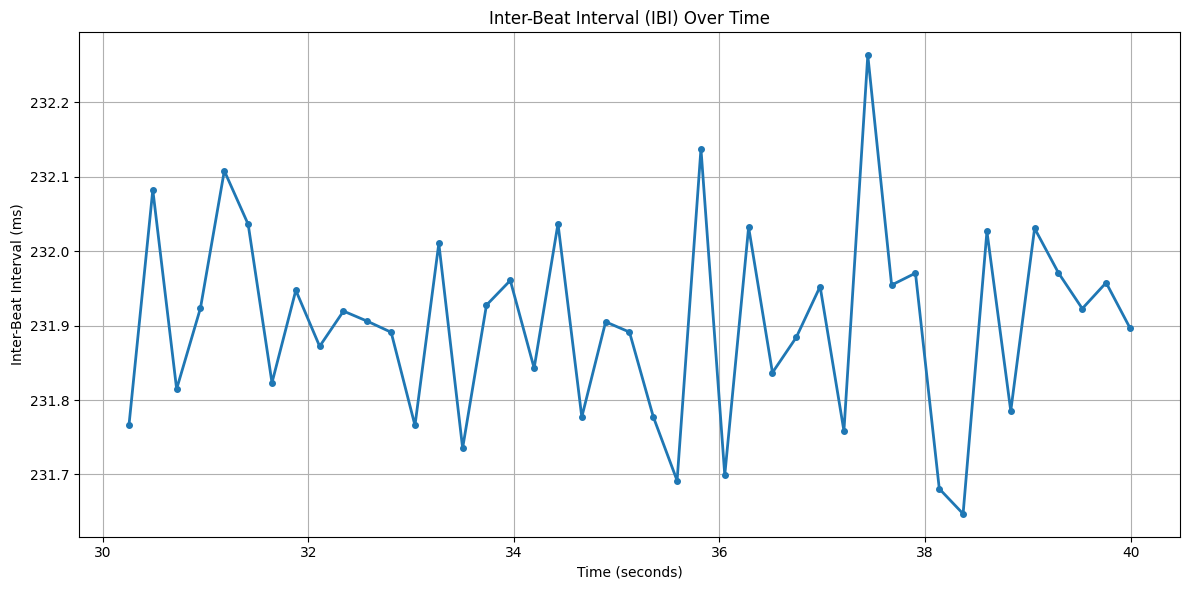

Number of beats detected: 44
Number of IBIs: 43


In [ ]:
# --- Question 1.3 ---
# Calculate Inter-Beat Intervals (IBI) and plot over time
peaks_time_array = np.array(peaks_time)

IBIs = np.diff(peaks_time_array)  

IBI_times = peaks_time_array[1:]  

# Plot IBI over time
plt.figure(figsize=(12, 6))
plt.plot(IBI_times / 1000, IBIs, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.title('Inter-Beat Interval (IBI) Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Inter-Beat Interval (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Number of beats detected: {len(peaks_time)}")
print(f"Number of IBIs: {len(IBIs)}")

In [13]:
# --- Question 1.4 ---
# Calculate Heart Rate Variability (HRV) Parameters

# 1. Mean Beat Interval
mean_IBI = np.mean(IBIs)

# 2. Standard Deviation (SDNN) 
SDNN = np.std(IBIs, ddof=1)  

# 3. Coefficient of Variation (CV) - SDNN as percentage of mean
CV = (SDNN / mean_IBI) * 100

# 4. RMSSD - Root Mean Square of Successive Differences
successive_differences = np.diff(IBIs)
RMSSD = np.sqrt(np.mean(successive_differences ** 2))

# 5. pNN50 - Percentage of successive NN intervals that differ by more than 50 ms
nn50_count = np.sum(np.abs(successive_differences) > 50)
pNN50 = (nn50_count / len(successive_differences)) * 100

# Display results
print("HEART RATE VARIABILITY (HRV) PARAMETERS")
print(f"Mean Beat Interval:  {mean_IBI:.2f} ms")
print(f"SDNN (Std Dev):      {SDNN:.2f} ms")
print(f"CV (Coefficient of Variation): {CV:.2f} %")
print(f"RMSSD:               {RMSSD:.2f} ms")
print(f"pNN50:               {pNN50:.2f} %")


HEART RATE VARIABILITY (HRV) PARAMETERS
Mean Beat Interval:  231.90 ms
SDNN (Std Dev):      0.13 ms
CV (Coefficient of Variation): 0.06 %
RMSSD:               0.21 ms
pNN50:               0.00 %
